In [2]:
from matplotlib import pyplot as plt
import re
import numpy as np
import pickle

In [3]:
with open('/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/circuit_depth_width/depths.p1.pkl', 'rb') as f:
    data = pickle.load(f)

In [4]:
data.keys()

dict_keys(['test_N2_W2', 'test_N3_W4', 'test_N4_W5', 'test_N4_W6', 'test_N5_W6', 'test_N7_W2', 'test_N7_W5', 'test_N8_W4', 'test_N8_W5'])

In [5]:
data['test_N2_W2']['abstract'].keys()

dict_keys(['depth', 'width', 'operations', 'circuit'])

In [7]:
[(data[f]['abstract']['width'], data[f]['abstract']['depth'], sum(data[f]['abstract']['operations'].values())) for f in data.keys()]

[(8, 13, 71),
 (24, 43, 295),
 (40, 70, 573),
 (48, 79, 737),
 (60, 103, 981),
 (28, 52, 401),
 (70, 114, 1260),
 (64, 108, 1141),
 (80, 130, 1505)]

In [ ]:
# NEED TO CHECK THESE VALUES - SWAP strat not working?

[(data[f]['hardware']['width'], data[f]['hardware']['depth'], sum(data[f]['hardware']['operations'].values())) for f in data.keys()]

[(8, 44, 453),
 (24, 200, 3534),
 (40, 449, 8747),
 (48, 537, 12503),
 (60, 763, 18376),
 (28, 266, 5096),
 (70, 987, 26586),
 (64, 1115, 22679),
 (80, 1271, 33256)]

In [9]:
widths = [data[f]['abstract']['width'] for f in data.keys()]
depths_abstract = [data[f]['abstract']['depth'] for f in data.keys()]
counts_abstract = [sum(data[f]['abstract']['operations'].values()) for f in data.keys()]

depths_hardware = [data[f]['hardware']['depth'] for f in data.keys()]
counts_hardware = [sum(data[f]['hardware']['operations'].values()) for f in data.keys()]

In [15]:
depths_abstract

[13, 43, 70, 79, 103, 52, 114, 108, 130]

In [16]:
p = np.polynomial.Polynomial.fit(widths, depths_abstract, 1)

In [21]:
p(40)

np.float64(68.07053291536054)

In [30]:
grid = np.linspace(widths[0], widths[-1], 100)
p_depth = np.polynomial.Polynomial.fit(widths, depths_abstract, 1)
p_depth_hardware = np.polynomial.Polynomial.fit(widths, depths_hardware, 2)
p_count = np.polynomial.Polynomial.fit(widths, counts_abstract, 1)
p_count_hardware = np.polynomial.Polynomial.fit(widths, counts_hardware, 2)


Text(0.5, 1.0, '2-qubit gate depth and count for QUBO-QAOA')

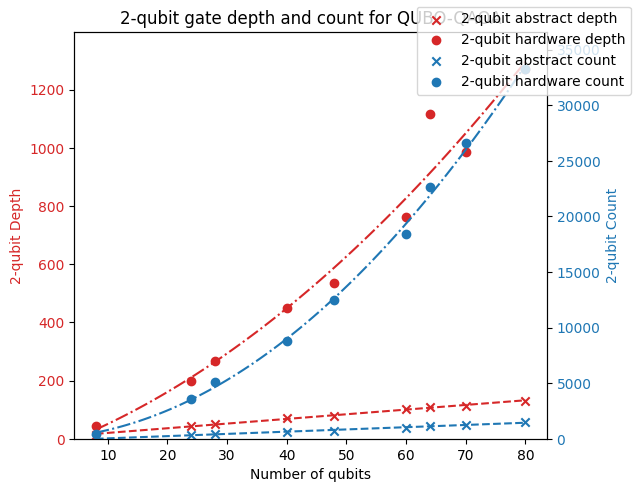

In [31]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.scatter(widths, depths_abstract, color=color, marker='x', label='2-qubit abstract depth')
ax1.scatter(widths, depths_hardware, color=color, label='2-qubit hardware depth')


ax1.plot(grid, p_depth(grid), color=color, linestyle='--')
ax1.plot(grid, p_depth_hardware(grid), color=color, linestyle='-.')


ax1.set_xlabel('Number of qubits')
ax1.set_ylabel('2-qubit Depth', color=color)
ax1.set_ylim(0, depths_hardware[-1] * 1.1)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.scatter(widths, counts_abstract, color=color, marker='x', label='2-qubit abstract count')
ax2.scatter(widths, counts_hardware, color=color, label='2-qubit hardware count')

ax2.plot(grid, p_count(grid), color=color, linestyle='--')
ax2.plot(grid, p_count_hardware(grid), color=color, linestyle='-.')

ax2.set_ylabel('2-qubit Count', color=color)
ax2.set_ylim(0, counts_hardware[-1] * 1.1)
ax2.tick_params(axis='y', labelcolor=color)


fig.legend()
fig.tight_layout()
ax1.set_title('2-qubit gate depth and count for QUBO-QAOA')

In [35]:
from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit.library import QAOAAnsatz
from qiskit import transpile

filename = 'test_N4_W5'
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

Q, hamiltonian, offset, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

# service = QiskitRuntimeService(name='eu_test_instance')
# backend = service.least_busy(min_num_qubits=num_qubits, operational=True, simulator=False) 
service = QiskitRuntimeService(name='us_instance')
backend = service.backend(name='ibm_boston')

qc = QAOAAnsatz(
    cost_operator=hamiltonian,
    reps = 1,
    flatten=True
)

tqc = transpile(qc, backend)


7728

In [36]:
sum(tqc.count_ops().values())

7728

In [33]:
sum(data[filename]['hardware']['operations'].values())

8747

In [40]:
from qubo_qaoa.utils.lr_qaoa import get_LR_qaoa_circuit
from qiskit.circuit import ParameterVector

phis = ParameterVector('ϕ', num_qubits)
abstract_qc, _ = get_LR_qaoa_circuit(       
        1, 0.7, 0.3, 40,
        hamiltonian,
        None, phis=phis, measure=True)


13:31:51 - qubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 75


In [41]:
abstract_qc.count_ops()

OrderedDict([('rzz', 332),
             ('ry', 120),
             ('rz', 80),
             ('measure', 40),
             ('barrier', 1)])

In [47]:
abstract_qc.draw(fold=-1)

┌──────────┐┌───────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                ┌───────────┐┌──────────┐┌──────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              ░ ┌─┐                                                                                                               

In [44]:
tlr_qc = transpile(abstract_qc, backend)

In [45]:
sum(tlr_qc.count_ops().values())

7545